In [160]:
import pandas as pd

DATA_PATH = "cvetovik2.csv"
df = pd.read_csv(DATA_PATH)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df

,product_id,name,rating,rating_count,num_flowers,aroma,composition_flowers,target_price,bonus,city
0,5300,Букет из 51 розы микс 35-40 см (Кения) под атл...,5.0,8,51.0,яркий,роза,3280.0,164,Москва
1,3469,Букет из 51 красной розы 35-40 см (Кения) под ...,4.6,590,51.0,яркий,роза,3290.0,165,Москва
2,4657,Букет из 25 альстромерий нежный микс под ленту,5.0,171,25.0,без запаха,альстромерия,3820.0,191,Москва
3,3265,Букет из 101 розы яркий микс 35-40 см (Кения),5.0,812,101.0,яркий,роза,7140.0,357,Москва
4,3982,Букет из 25 розовых гвоздик в стильной упаковке,4.7,599,25.0,сладкий,гвоздика,3290.0,165,Москва
5,5643,Букет из 35 красных роз (Кения) 50 см под ленту,4.7,165,35.0,яркий,роза,4170.0,209,Москва
6,4007,Букет из 101 розы нежный микс 35-40 см (Россия...,4.8,753,101.0,классический,роза,7140.0,357,Москва
7,4989,Букет из 51 альстромерий микс под ленту,5.0,4,51.0,без запаха,альстромерия,6590.0,330,Москва
8,2937,Букет из 35 роз микс 35-40 см (Кения) под атла...,4.7,838,35.0,яркий,роза,3170.0,159,Москва
9,1881,Букет из 15 гербер стандарт микс в стильной уп...,4.5,536,15.0,свежий,гербера,3390.0,170,Москва


In [162]:
#сколько пропусков и в каких местах смотрим
rows_with_na = df[df.isna().any(axis=1)]
print("Количество строк с пропусками:", len(rows_with_na))
rows_with_na

Количество строк с пропусками: 81


,product_id,name,rating,rating_count,num_flowers,aroma,composition_flowers,target_price,bonus,city
135,4400,Букет цветов Струны души S,5.0,677,15.0,NaN,"роза, хризантема",9461.0,474,Москва
191,123,Сантини белая ромашка,5.0,751,NaN,сладкий,хризантема,251.0,13,Москва
192,78,Сантини микс,5.0,944,NaN,сладкий,хризантема,251.0,13,Москва
341,542,Букет из 15 матрикарий в стильной упаковке,4.5,331,15.0,NaN,ромашка,5240.0,262,Москва
343,5159,Букет цветов Летний сад,4.6,166,11.0,NaN,ромашка,4841.0,243,Москва
345,5160,Букет цветов Солнечный рай,4.9,197,25.0,NaN,ромашка,9965.0,499,Москва
346,5609,Букет из 11 матрикарий в стильной упаковке,4.8,188,11.0,NaN,ромашка,3738.0,187,Москва
348,5094,Букет цветов Летнее поле,4.5,147,10.0,NaN,"хризантема, ромашка",6048.0,303,Москва
350,2004,Букет из 35 матрикарий в дизайнерской упаковке,4.9,630,35.0,NaN,ромашка,10994.0,550,Москва
351,2156,Букет из 49 матрикарий в дизайнерской упаковке,4.7,492,49.0,NaN,ромашка,15131.0,757,Москва


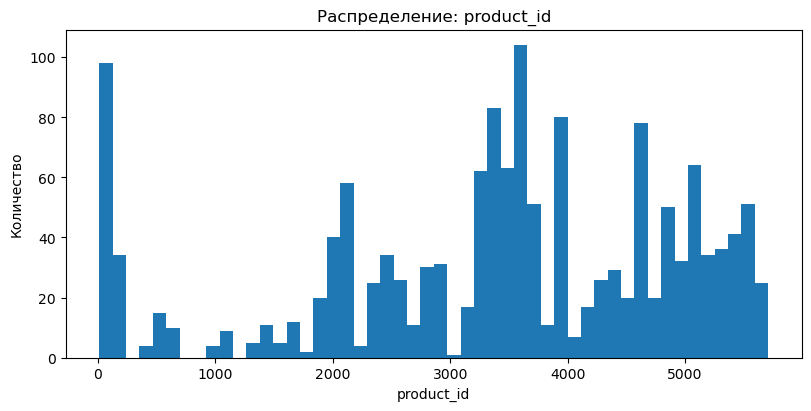

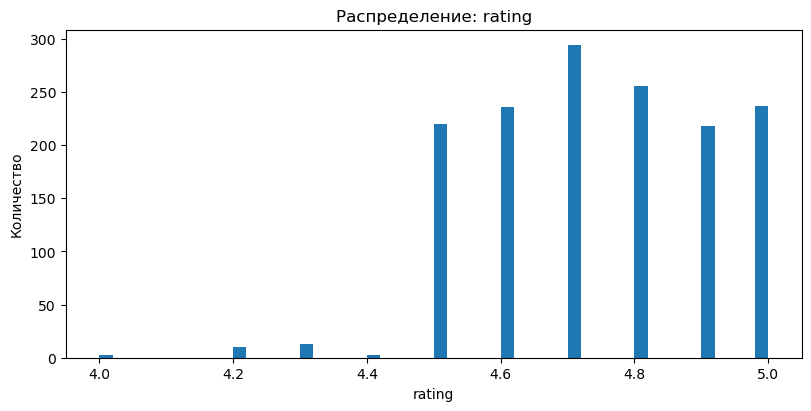

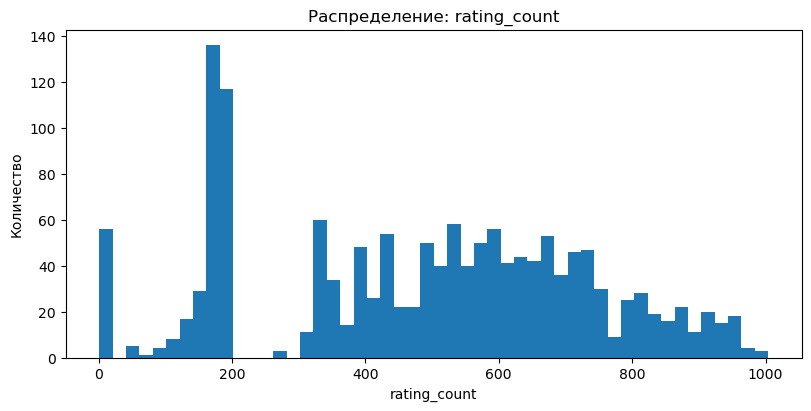

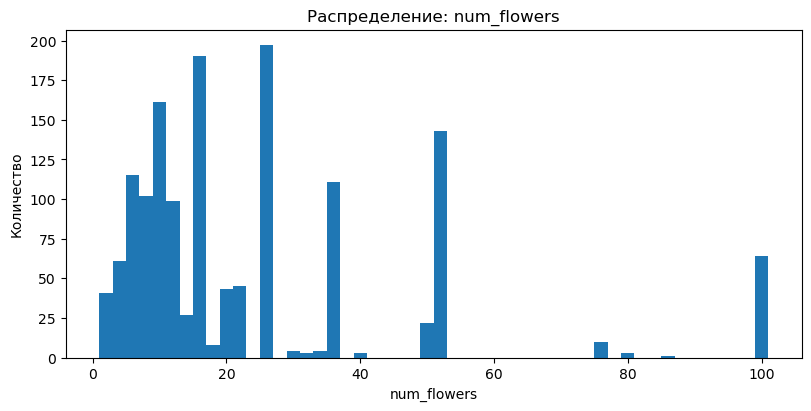

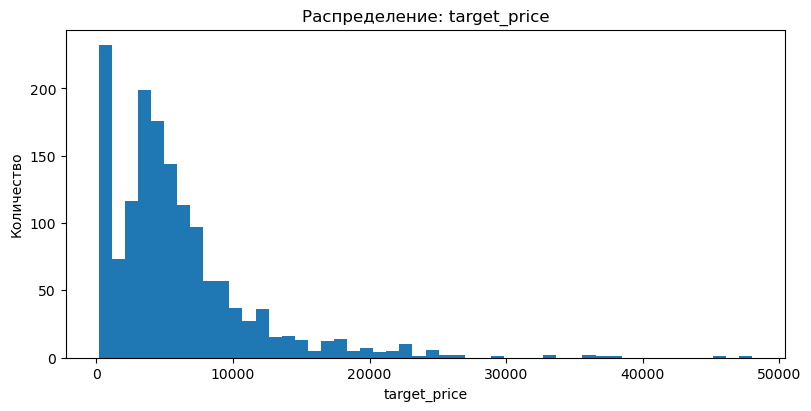

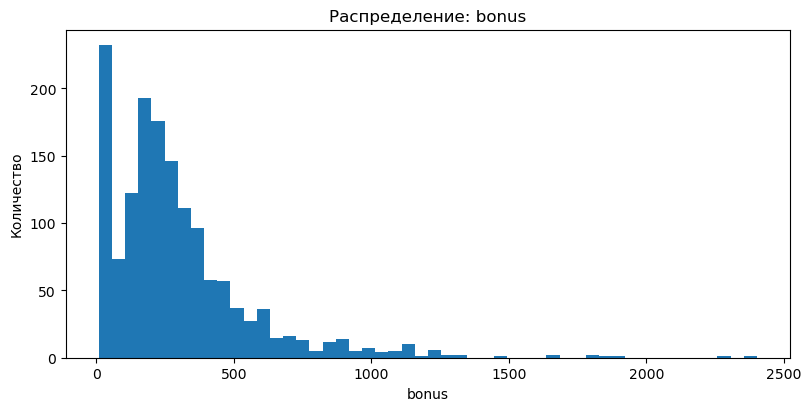

In [168]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.hist(df[col].dropna(), bins=50)
    ax.set_title(f"Распределение: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Количество")
    plt.show()

In [170]:
#2 обработка данных
import pandas as pd
import numpy as np

df_clean = df.copy()

num_cols = [c for c in df_clean.columns if pd.api.types.is_numeric_dtype(df_clean[c])]
for c in num_cols:
    if df_clean[c].isna().any():
        median_value = df_clean[c].median()
        df_clean[c] = df_clean[c].fillna(median_value)
        print(f"Числовой столбец '{c}' заполнен медианой ({median_value:.2f})")

cat_cols = [c for c in df_clean.columns if df_clean[c].dtype == "object"]

for c in cat_cols:
    if df_clean[c].isna().any():
        top = df_clean[c].mode(dropna=True)
        fill_val = top.iloc[0] if not top.empty else "unknown"
        df_clean[c] = df_clean[c].fillna(fill_val)
        print(f"Категориальный столбец '{c}'  заполнен модой: {repr(fill_val)}")

def cap_outliers_iqr(series, k=1.5):
    """обрезаем выбросы по IQR"""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - k * iqr
    high = q3 + k * iqr
    return series.clip(lower=low, upper=high)

for c in num_cols:
    before_std = df_clean[c].std()
    df_clean[c] = cap_outliers_iqr(df_clean[c])
    after_std = df_clean[c].std()
    if not np.isclose(before_std, after_std):
        print(f"Выбросы обработаны в '{c}': std {before_std:.2f} -> {after_std:.2f}")

print("\nПроверка пропусков после обработки:")
print(df_clean.isna().sum())

df_clean.to_csv("cvetovik2_clean.csv", index=False)

Числовой столбец 'num_flowers' → заполнен медианой (15.00)
Категориальный столбец 'aroma' → заполнен модой: 'без запаха'
Категориальный столбец 'composition_flowers' → заполнен модой: 'хризантема'
Выбросы обработаны в 'rating': std 0.18 → 0.18
Выбросы обработаны в 'num_flowers': std 22.38 → 15.23
Выбросы обработаны в 'target_price': std 5354.69 → 4024.29
Выбросы обработаны в 'bonus': std 267.73 → 201.32

Проверка пропусков после обработки:
product_id             0
name                   0
rating                 0
rating_count           0
num_flowers            0
aroma                  0
composition_flowers    0
target_price           0
bonus                  0
city                   0
dtype: int64


In [32]:
#2 в кат пер
df_clean = pd.read_csv("cvetovik2_clean.csv")
print("\nУникальные значения AROMA")
print(df_clean["aroma"].unique())

print("\nУникальные значения CITY")
print(df_clean["city"].unique())


Уникальные значения AROMA
['яркий' 'без запаха' 'сладкий' 'классический' 'свежий' 'фруктовый'
 'опьяняющий' 'медовый' 'травяной' 'лёгкий' 'пряный']

Уникальные значения CITY
['Москва' 'Санкт-Петербург' 'Псков' 'Краснодар' 'Казань']


In [172]:
# Категориальные в числовые 
import pandas as pd

df = pd.read_csv("cvetovik2_clean.csv")

aroma_vals = sorted(df["aroma"].astype(str).unique())
city_vals  = sorted(df["city"].astype(str).unique())

aroma_to_id = {name: i+1 for i, name in enumerate(aroma_vals)}
city_to_id  = {name: i+1 for i, name in enumerate(city_vals)}

df["aroma_id"] = df["aroma"].astype(str).map(aroma_to_id).astype(int)
df["city_id"]  = df["city"].astype(str).map(city_to_id).astype(int)

pd.DataFrame({"aroma": aroma_vals, "aroma_id": [aroma_to_id[a] for a in aroma_vals]}).to_csv(
    "aroma_mapping.csv", index=False
)
pd.DataFrame({"city": city_vals, "city_id": [city_to_id[c] for c in city_vals]}).to_csv(
    "city_mapping.csv", index=False
)
df.to_csv("cvetovik2_with_ids.csv", index=False)
print("Сохранено в: cvetovik2_with_ids.csv")
print("\nМаппинг AROMA:", aroma_to_id)
print("Маппинг CITY:", city_to_id)
df[["aroma", "aroma_id", "city", "city_id"]].head(10)

Готово. Сохранено в: cvetovik2_with_ids.csv

Маппинг AROMA: {'без запаха': 1, 'классический': 2, 'лёгкий': 3, 'медовый': 4, 'опьяняющий': 5, 'пряный': 6, 'свежий': 7, 'сладкий': 8, 'травяной': 9, 'фруктовый': 10, 'яркий': 11}
Маппинг CITY: {'Казань': 1, 'Краснодар': 2, 'Москва': 3, 'Псков': 4, 'Санкт-Петербург': 5}


,aroma,aroma_id,city,city_id
0,яркий,11,Москва,3
1,яркий,11,Москва,3
2,без запаха,1,Москва,3
3,яркий,11,Москва,3
4,сладкий,8,Москва,3
5,яркий,11,Москва,3
6,классический,2,Москва,3
7,без запаха,1,Москва,3
8,яркий,11,Москва,3
9,свежий,7,Москва,3


In [174]:
#маппим все. водно
import pandas as pd

DATA_PATH = "cvetovik2_with_ids.csv" 
AROMA_MAP_PATH = "aroma_mapping.csv"
CITY_MAP_PATH  = "city_mapping.csv"

OUT_WITH_IDS   = "cvetovik2_with_ids_mapped.csv"
OUT_NUMERIC    = "cvetovik2_with_ids_mapped_numeric_only_id.csv"

df = pd.read_csv(DATA_PATH)
aroma_map = pd.read_csv(AROMA_MAP_PATH)
city_map  = pd.read_csv(CITY_MAP_PATH)

def norm(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip()

if "aroma" in df.columns:
    df["aroma"] = norm(df["aroma"]).fillna("")
if "city" in df.columns:
    df["city"] = norm(df["city"]).fillna("")

if "aroma" in aroma_map.columns:
    aroma_map["aroma"] = norm(aroma_map["aroma"])
if "city" in city_map.columns:
    city_map["city"] = norm(city_map["city"])

if "aroma_id" in aroma_map.columns:
    aroma_map["aroma_id"] = aroma_map["aroma_id"].astype(int)
if "city_id" in city_map.columns:
    city_map["city_id"] = city_map["city_id"].astype(int)

df_mapped = df.copy()
for col in ["aroma_id", "city_id"]:
    if col in df_mapped.columns:
        df_mapped.drop(columns=[col], inplace=True)

df_mapped = df_mapped.merge(aroma_map[["aroma", "aroma_id"]], on="aroma", how="left")
df_mapped = df_mapped.merge(city_map[["city", "city_id"]], on="city", how="left")

missing_aroma = int(df_mapped["aroma_id"].isna().sum())
missing_city  = int(df_mapped["city_id"].isna().sum())

unknown_aromas = sorted(df_mapped.loc[df_mapped["aroma_id"].isna(), "aroma"].dropna().unique().tolist())
unknown_cities = sorted(df_mapped.loc[df_mapped["city_id"].isna(), "city"].dropna().unique().tolist())

df_mapped.to_csv(OUT_WITH_IDS, index=False)
print(f"\nSaved: {OUT_WITH_IDS}  (shape={df_mapped.shape})")

cols_to_drop = [c for c in ["aroma", "city"] if c in df_mapped.columns]
df_numeric = df_mapped.drop(columns=cols_to_drop)
df_numeric.to_csv(OUT_NUMERIC, index=False)
print(f"Saved: {OUT_NUMERIC}  (shape={df_numeric.shape})")

print("\nPreview (mapped):")
print(df_mapped.head(5))
print("\nPreview (numeric):")
print(df_numeric.head(5))


Saved: cvetovik2_with_ids_mapped.csv  (shape=(1490, 12))
Saved: cvetovik2_with_ids_mapped_numeric_only_id.csv  (shape=(1490, 10))

Preview (mapped):
   product_id                                               name  rating  \
0        5300  Букет из 51 розы микс 35-40 см (Кения) под атл...     5.0   
1        3469  Букет из 51 красной розы 35-40 см (Кения) под ...     4.6   
2        4657     Букет из 25 альстромерий нежный микс под ленту     5.0   
3        3265      Букет из 101 розы яркий микс 35-40 см (Кения)     5.0   
4        3982    Букет из 25 розовых гвоздик в стильной упаковке     4.7   

   rating_count  num_flowers       aroma composition_flowers  target_price  \
0             8         49.0       яркий                роза        3280.0   
1           590         49.0       яркий                роза        3290.0   
2           171         25.0  без запаха        альстромерия        3820.0   
3           812         49.0       яркий                роза        7140.0   
4  

In [176]:
# маппим переменную цветы в составе
import pandas as pd

SRC = "cvetovik2_with_ids_mapped_numeric_only_id.csv"
OUT_WITH_TEXT = "cvetovik2_with_comp_mapped.csv"
OUT_NUMERIC   = "cvetovik2_numeric_comp_id.csv"
COMP_MAP      = "composition_flowers_mapping.csv"

df = pd.read_csv(SRC)

comp_norm = df["composition_flowers"].astype("string").str.strip().fillna("")
unique_vals = sorted(comp_norm.unique().tolist())
comp_to_id = {name: i + 1 for i, name in enumerate(unique_vals)}

map_df = pd.DataFrame({"composition_flowers": unique_vals,
                       "composition_flowers_id": [comp_to_id[v] for v in unique_vals]})
map_df.to_csv(COMP_MAP, index=False)

df_with_text = df.copy()
df_with_text["composition_flowers"] = comp_norm
df_with_text["composition_flowers_id"] = df_with_text["composition_flowers"].map(comp_to_id).astype(int)

missing = int(df_with_text["composition_flowers_id"].isna().sum())

df_with_text.to_csv(OUT_WITH_TEXT, index=False)
df_numeric = df_with_text.drop(columns=["composition_flowers"])
df_numeric.to_csv(OUT_NUMERIC, index=False)

print(f"откуда взяли: {SRC}")
print(f"сохранено (текст + comp_id): {OUT_WITH_TEXT}")
print(f"Сохранено (только comp_id):  {OUT_NUMERIC}")
print(f"Таблица соответствий:        {COMP_MAP}")
print(f"Всего уникальных значений composition_flowers: {len(unique_vals)}")

print("\nPreview mapped (with text):")
print(df_with_text.head(5))
print("\nPreview numeric (no text):")
print(df_numeric.head(5))

откуда взяли: cvetovik2_with_ids_mapped_numeric_only_id.csv
сохранено (текст + comp_id): cvetovik2_with_comp_mapped.csv
Сохранено (только comp_id):  cvetovik2_numeric_comp_id.csv
Таблица соответствий:        composition_flowers_mapping.csv
Всего уникальных значений composition_flowers: 38

Preview mapped (with text):
   product_id                                               name  rating  \
0        5300  Букет из 51 розы микс 35-40 см (Кения) под атл...     5.0   
1        3469  Букет из 51 красной розы 35-40 см (Кения) под ...     4.6   
2        4657     Букет из 25 альстромерий нежный микс под ленту     5.0   
3        3265      Букет из 101 розы яркий микс 35-40 см (Кения)     5.0   
4        3982    Букет из 25 розовых гвоздик в стильной упаковке     4.7   

   rating_count  num_flowers composition_flowers  target_price  bonus  \
0             8         49.0                роза        3280.0    164   
1           590         49.0                роза        3290.0    165   
2    

In [184]:
# бейзлайн на подготовленном датасете
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

df = pd.read_csv("cvetovik2_numeric_comp_id.csv")
target_col = "target_price"

global_median = df[target_col].median()
df["pred_baseline_median"] = global_median

y_true = df[target_col].values
y_pred = df["pred_baseline_median"].values

mae  = mean_absolute_error(y_true, y_pred)
rmse_val = root_mean_squared_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape_val = mape(y_true, y_pred)

print(f"Глобальная медиана: {global_median:.2f}")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse_val:.2f}")
print(f"MAPE: {mape_val:.2f}%")
print(f"R2  : {r2:.3f}")


Глобальная медиана: 4610.00
MAE : 3108.11
RMSE: 4108.80
MAPE: 253.92%
R²  : -0.043


In [104]:
#6 делим датасет
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cvetovik2_numeric_comp_id.csv")
df_trainval, df_test = train_test_split(
    df, test_size=0.20, random_state=42, shuffle=True
)

df_train, df_val = train_test_split(
    df_trainval, test_size=0.25, random_state=42, shuffle=True
)

print("train:", df_train.shape)
print("val:  ", df_val.shape)
print("test: ", df_test.shape)
df_train.to_csv("train.csv", index=True)
df_val.to_csv("val.csv", index=True)
df_test.to_csv("test.csv", index=True)

Размеры:
train: (894, 12)
val:   (298, 12)
test:  (298, 12)


In [124]:
TARGET = "target_price"
EXCLUDE = ["bonus", ]

def get_Xy(df):
    X = df.drop(columns=[TARGET] + [c for c in EXCLUDE if c in df.columns])
    y = df[TARGET]
    num_cols = X.select_dtypes(include="number").columns.tolist()
    return X[num_cols], y, num_cols

DecisionTree — RMSE: 2,487.42 | MAE: 1,715.55 | R²: 0.6055


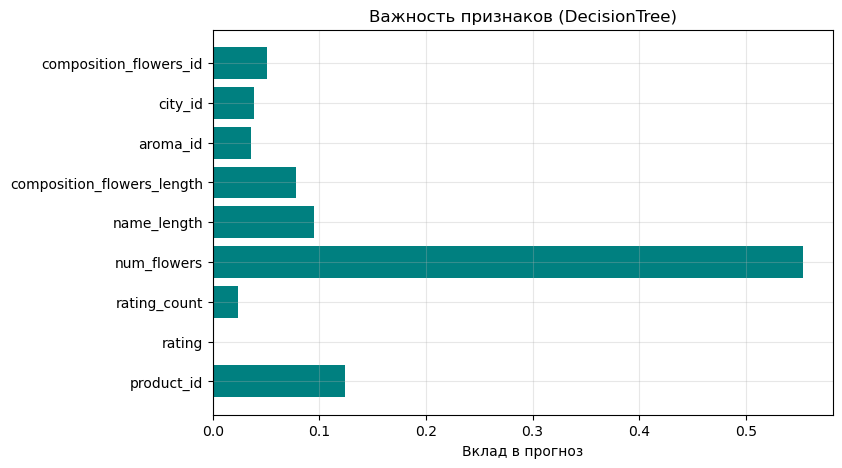

In [186]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

X_train, y_train, num_cols = get_Xy(df_train)
X_val,   y_val,   _        = get_Xy(df_val)

tree = DecisionTreeRegressor(
    max_depth=6,        
    min_samples_leaf=10,
    random_state=42
)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

print(f"DecisionTree — RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f}")

importances = tree.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(num_cols, importances, color="teal")
plt.title("Важность признаков (DecisionTree)")
plt.xlabel("Вклад в прогноз")
plt.grid(alpha=0.3)
plt.show()


Fitting 5 folds for each of 1152 candidates, totalling 5760 fits
Лучшие параметры: {'ccp_alpha': 0.005, 'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Лучший RMSE на CV: 1726.32

Val — RMSE: 1,989.26 | MAE: 1,041.09 | R2: 0.7477


/opt/anaconda3/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


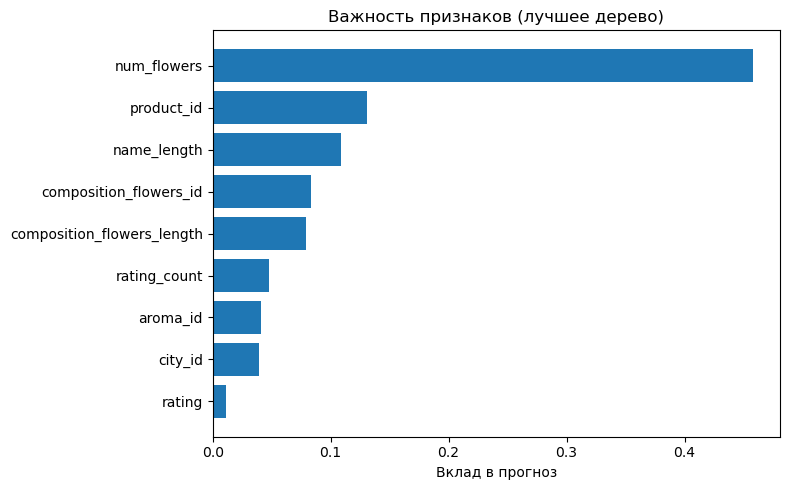

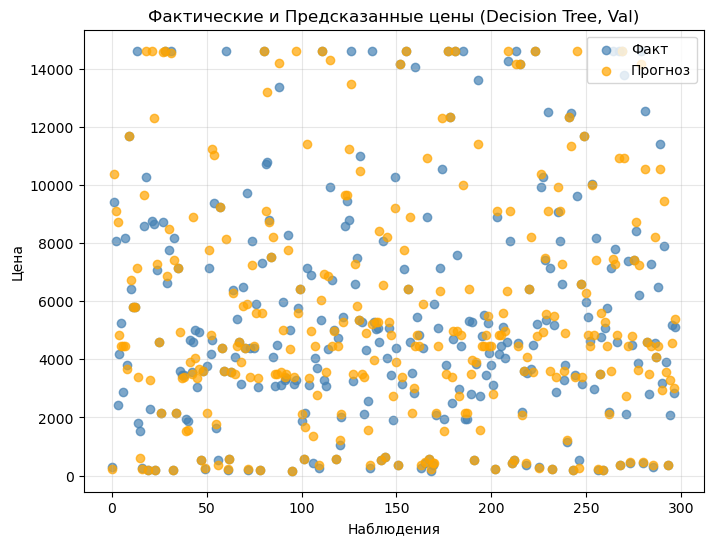

In [189]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, r2_score, mean_squared_error
)
TARGET = "target_price"
EXCLUDE = ["bonus"] 

def get_Xy(df):
    X = df.drop(columns=[TARGET] + [c for c in EXCLUDE if c in df.columns])
    y = df[TARGET].astype(float)
    num_cols = X.select_dtypes(include="number").columns.tolist()
    return X[num_cols], y, num_cols

X_train, y_train, num_cols = get_Xy(df_train)
X_val,   y_val,   _        = get_Xy(df_val)

param_grid = {
    "max_depth": [None, 4, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
    "ccp_alpha": [0.0, 0.0005, 0.001, 0.005]
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший RMSE на CV:", round(-grid.best_score_, 2))

best_tree = grid.best_estimator_
y_pred = best_tree.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

print(f"\nVal — RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R2: {r2:.4f}")

importances = best_tree.feature_importances_
imp_sorted_idx = np.argsort(importances)

plt.figure(figsize=(8,5))
plt.barh(np.array(num_cols)[imp_sorted_idx], importances[imp_sorted_idx])
plt.title("Важность признаков (лучшее дерево)")
plt.xlabel("Вклад в прогноз")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(range(len(y_val)), y_val,  alpha=0.7, label="Факт",        color="steelblue")
plt.scatter(range(len(y_val)), y_pred, alpha=0.7, label="Прогноз",     color="orange")
plt.title("Фактические и Предсказанные цены (Decision Tree, Val)")
plt.xlabel("Наблюдения")
plt.ylabel("Цена")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [140]:
#8 взяла меньшк макс глубину тк до этого было переобучение
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

params = {
    "max_depth": 8,          
    "min_samples_split": 10,  
    "min_samples_leaf": 5,   
    "ccp_alpha": 0.005,       
    "random_state": 42
}

better_tree = DecisionTreeRegressor(**params)
better_tree.fit(X_train, y_train)

y_train_pred = better_tree.predict(X_train)
y_val_pred   = better_tree.predict(X_val)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train  = mean_absolute_error(y_train, y_train_pred)
r2_train   = r2_score(y_train, y_train_pred)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val  = mean_absolute_error(y_val, y_val_pred)
r2_val   = r2_score(y_val, y_val_pred)

print(f"Train | RMSE: {rmse_train:,.2f} | MAE: {mae_train:,.2f} | R²: {r2_train:.4f}")
print(f"Val   | RMSE: {rmse_val:,.2f} | MAE: {mae_val:,.2f} | R²: {r2_val:.4f}")


Train | RMSE: 1,559.90 | MAE: 986.56 | R²: 0.8530
Val   | RMSE: 2,171.43 | MAE: 1,357.19 | R²: 0.6994


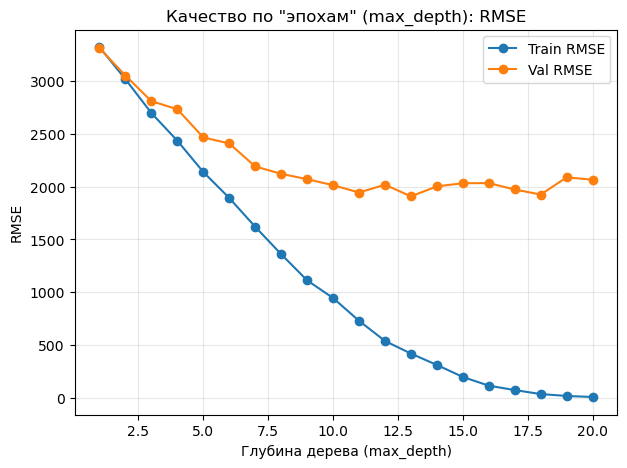

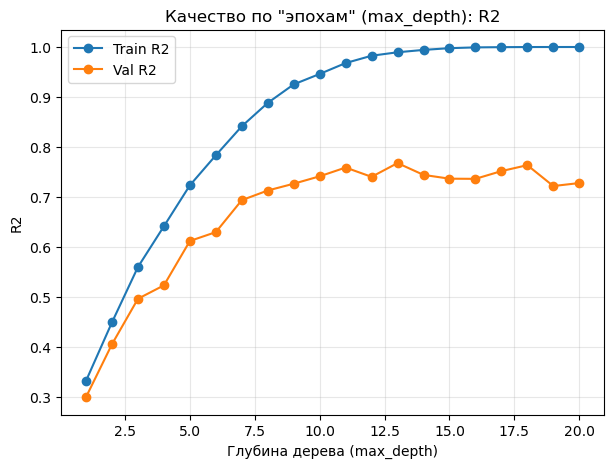

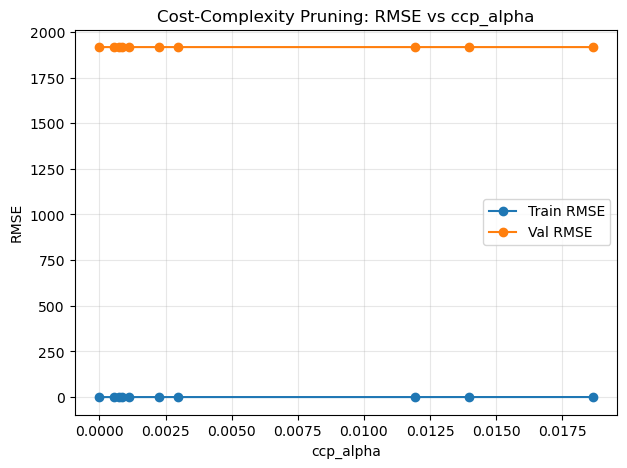

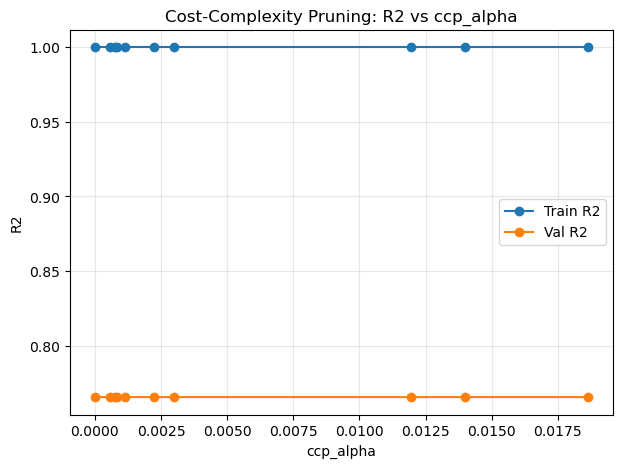

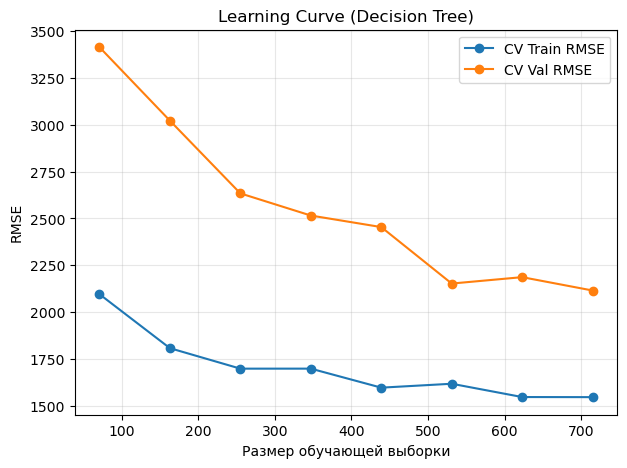

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

TARGET = "target_price"
EXCLUDE = ["bonus"] 
def get_Xy(df):
    X = df.drop(columns=[TARGET] + [c for c in EXCLUDE if c in df.columns])
    y = df[TARGET].astype(float)
    num_cols = X.select_dtypes(include="number").columns.tolist()
    return X[num_cols], y, num_cols

X_train, y_train, num_cols = get_Xy(df_train)
X_val,   y_val,   _        = get_Xy(df_val)

depths = list(range(1, 21))
rmse_tr, rmse_val, r2_tr, r2_val = [], [], [], []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    y_tr = m.predict(X_train)
    y_pr = m.predict(X_val)
    rmse_tr.append(np.sqrt(mean_squared_error(y_train, y_tr)))
    rmse_val.append(np.sqrt(mean_squared_error(y_val, y_pr)))
    r2_tr.append(r2_score(y_train, y_tr))
    r2_val.append(r2_score(y_val, y_pr))

plt.figure(figsize=(7,5))
plt.plot(depths, rmse_tr, marker='o', label='Train RMSE')
plt.plot(depths, rmse_val, marker='o', label='Val RMSE')
plt.xlabel("Глубина дерева (max_depth)")
plt.ylabel("RMSE")
plt.title("Качество по \"эпохам\" (max_depth): RMSE")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(7,5))
plt.plot(depths, r2_tr, marker='o', label='Train R2')
plt.plot(depths, r2_val, marker='o', label='Val R2')
plt.xlabel("Глубина дерева (max_depth)")
plt.ylabel("R2")
plt.title("Качество по \"эпохам\" (max_depth): R2")
plt.legend(); plt.grid(alpha=0.3); plt.show()

path = DecisionTreeRegressor(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(np.round(path.ccp_alphas, 6)) 
ccp_alphas = [a for a in ccp_alphas if a <= 0.02]   

rmse_tr_a, rmse_val_a, r2_tr_a, r2_val_a = [], [], [], []
for a in ccp_alphas:
    m = DecisionTreeRegressor(ccp_alpha=a, random_state=42, max_depth=None)
    m.fit(X_train, y_train)
    y_tr = m.predict(X_train)
    y_pr = m.predict(X_val)
    rmse_tr_a.append(np.sqrt(mean_squared_error(y_train, y_tr)))
    rmse_val_a.append(np.sqrt(mean_squared_error(y_val, y_pr)))
    r2_tr_a.append(r2_score(y_train, y_tr))
    r2_val_a.append(r2_score(y_val, y_pr))

plt.figure(figsize=(7,5))
plt.plot(ccp_alphas, rmse_tr_a, marker='o', label='Train RMSE')
plt.plot(ccp_alphas, rmse_val_a, marker='o', label='Val RMSE')
plt.xlabel("ccp_alpha")
plt.ylabel("RMSE")
plt.title("Cost-Complexity Pruning: RMSE vs ccp_alpha")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(7,5))
plt.plot(ccp_alphas, r2_tr_a, marker='o', label='Train R2')
plt.plot(ccp_alphas, r2_val_a, marker='o', label='Val R2')
plt.xlabel("ccp_alpha")
plt.ylabel("R2")
plt.title("Cost-Complexity Pruning: R2 vs ccp_alpha")
plt.legend(); plt.grid(alpha=0.3); plt.show()

from sklearn.model_selection import learning_curve
m0 = DecisionTreeRegressor(max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    m0, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1, shuffle=True, random_state=42
)
train_rmse_lc = -train_scores.mean(axis=1)
val_rmse_lc   = -val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_rmse_lc, marker='o', label='CV Train RMSE')
plt.plot(train_sizes, val_rmse_lc, marker='o', label='CV Val RMSE')
plt.xlabel("Размер обучающей выборки")
plt.ylabel("RMSE")
plt.title("Learning Curve (Decision Tree)")
plt.legend(); plt.grid(alpha=0.3); plt.show()


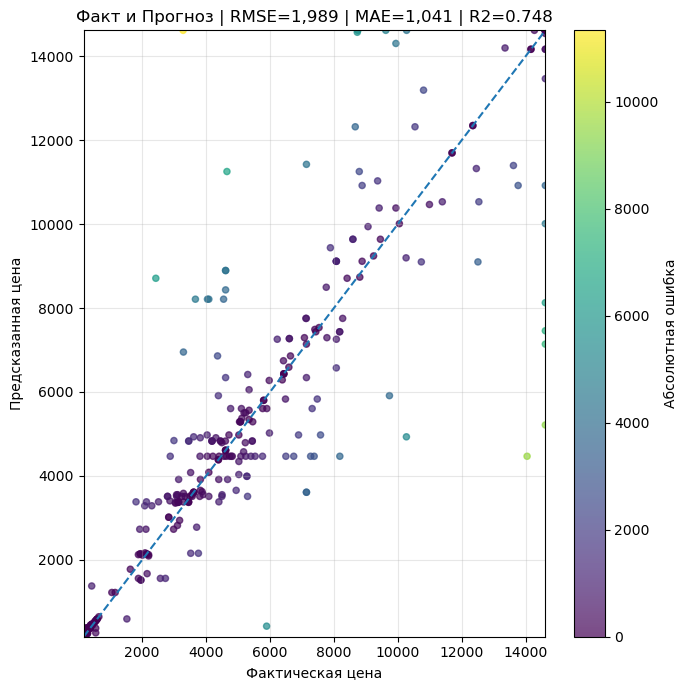

In [195]:
import numpy as np
import matplotlib.pyplot as plt

true = np.asarray(y_val)
pred = np.asarray(y_pred)

abs_err = np.abs(true - pred)

plt.figure(figsize=(7,7))
sc = plt.scatter(true, pred, c=abs_err, s=20, alpha=0.7)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, linestyle='--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
try:
    plt.title(f"Факт и Прогноз | RMSE={rmse:,.0f} | MAE={mae:,.0f} | R2={r2:.3f}")
except NameError:
    plt.title("Факт и Прогноз")

cb = plt.colorbar(sc)
cb.set_label("Абсолютная ошибка")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Лучшие параметры (my-tree): max_depth=12, min_samples_leaf=3, min_samples_split=2
Val — RMSE: 1,943.62
Train — RMSE: 1,017.94 | MAE: 578.01 | R²: 0.9374
Val   — RMSE: 1,943.62 | MAE: 1,196.70 | R²: 0.7592


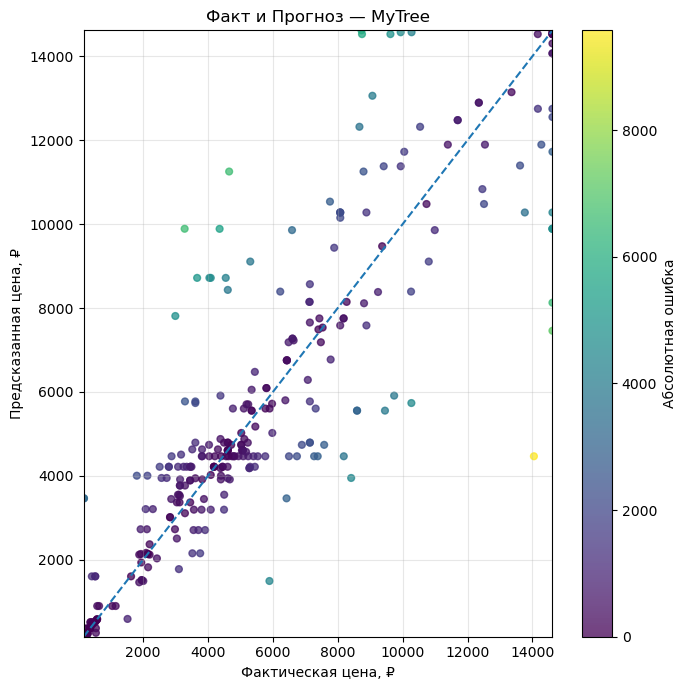

In [197]:
#9 наконец-то..
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

class _Node:
    __slots__ = ("feature", "thr", "left", "right", "value")
    def __init__(self, value=None, feature=None, thr=None, left=None, right=None):
        self.value = value
        self.feature = feature
        self.thr = thr
        self.left = left
        self.right = right

class MyTree:
    def __init__(self, max_depth=6, min_samples_leaf=1, min_samples_split=2, random_state=None):
        self.max_depth = int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_samples_split = int(min_samples_split)
        self.random_state = random_state
        self.root_ = None

    def _sse(self, y):
        if y.size == 0:
            return 0.0
        mu = y.mean()
        return np.sum((y - mu) ** 2)

    def _best_split_for_feature(self, xj, y):
        order = np.argsort(xj)
        x_sorted = xj[order]
        y_sorted = y[order]

        diffs = np.diff(x_sorted)
        idxs = np.where(diffs != 0)[0]
        if idxs.size == 0:
            return None, -np.inf

        c1 = np.cumsum(y_sorted)
        c2 = np.cumsum(y_sorted ** 2)
        n = y_sorted.size
        best_thr = None
        best_gain = -np.inf
        total_sse = self._sse(y_sorted)

        for i in idxs:
            nL = i + 1
            nR = n - nL
            if nL < self.min_samples_leaf or nR < self.min_samples_leaf:
                continue

            sumL, sum2L = c1[i], c2[i]
            muL = sumL / nL
            sseL = sum2L - nL * muL * muL

            sumR, sum2R = c1[-1] - sumL, c2[-1] - sum2L
            muR = sumR / nR
            sseR = sum2R - nR * muR * muR

            gain = total_sse - (sseL + sseR)
            if gain > best_gain:
                best_gain = gain
                best_thr = (x_sorted[i] + x_sorted[i+1]) / 2.0

        return best_thr, best_gain

    def _best_split(self, X, y):
        best_feat, best_thr, best_gain = None, None, -np.inf
        for j in range(X.shape[1]):
            thr, gain = self._best_split_for_feature(X[:, j], y)
            if gain > best_gain:
                best_gain = gain
                best_thr = thr
                best_feat = j
        return best_feat, best_thr, best_gain

    def _build(self, X, y, depth):
        n = y.size
        if depth >= self.max_depth or n < self.min_samples_split or np.unique(y).size == 1:
            return _Node(value=float(y.mean()))

        feat, thr, gain = self._best_split(X, y)
        if feat is None or not np.isfinite(gain) or gain <= 1e-12:
            return _Node(value=float(y.mean()))

        mask = X[:, feat] <= thr
        if mask.sum() == 0 or mask.sum() == n:
            return _Node(value=float(y.mean()))

        left = self._build(X[mask], y[mask], depth+1)
        right = self._build(X[~mask], y[~mask], depth+1)
        return _Node(feature=feat, thr=thr, left=left, right=right)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.root_ = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        while node.left is not None and node.right is not None:
            if x[node.feature] <= node.thr:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(row, self.root_) for row in X])


TARGET = "target_price"
EXCLUDE = ["bonus"]

def get_Xy_numeric(df):
    X = df.drop(columns=[TARGET] + [c for c in EXCLUDE if c in df.columns])
    y = df[TARGET].astype(float)
    num_cols = X.select_dtypes(include="number").columns.tolist()
    return X[num_cols].values, y.values, num_cols

X_train, y_train, num_cols = get_Xy_numeric(df_train)
X_val,   y_val,   _        = get_Xy_numeric(df_val)

param_grid = {
    "max_depth": [6, 8, 10, 12],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10]
}

best = {"rmse": np.inf, "params": None, "model": None}

for md in param_grid["max_depth"]:
    for msl in param_grid["min_samples_leaf"]:
        for mss in param_grid["min_samples_split"]:
            m = MyStupidTreeRegressor(max_depth=md, min_samples_leaf=msl, min_samples_split=mss, random_state=42)
            m.fit(X_train, y_train)
            y_pred_val = m.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
            if rmse < best["rmse"]:
                best.update({"rmse": rmse, "params": (md, msl, mss), "model": m})

print(f"Лучшие параметры (my-tree): max_depth={best['params'][0]}, "
      f"min_samples_leaf={best['params'][1]}, min_samples_split={best['params'][2]}")
print(f"Val — RMSE: {best['rmse']:,.2f}")


best_model = best["model"]
y_tr_pred = best_model.predict(X_train)
y_v_pred  = best_model.predict(X_val)

rmse_tr = np.sqrt(mean_squared_error(y_train, y_tr_pred))
mae_tr  = mean_absolute_error(y_train, y_tr_pred)
r2_tr   = r2_score(y_train, y_tr_pred)

rmse_v = np.sqrt(mean_squared_error(y_val, y_v_pred))
mae_v  = mean_absolute_error(y_val, y_v_pred)
r2_v   = r2_score(y_val, y_v_pred)

print(f"Train — RMSE: {rmse_tr:,.2f} | MAE: {mae_tr:,.2f} | R²: {r2_tr:.4f}")
print(f"Val   — RMSE: {rmse_v:,.2f} | MAE: {mae_v:,.2f} | R²: {r2_v:.4f}")

true = y_val
pred = y_v_pred
abs_err = np.abs(true - pred)

plt.figure(figsize=(7,7))
sc = plt.scatter(true, pred, c=abs_err, s=24, alpha=0.75)
lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
plt.plot(lims, lims, linestyle='--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Факт и Прогноз — MyTree")
cb = plt.colorbar(sc); cb.set_label("Абсолютная ошибка")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [201]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_tree_sklearn = grid.best_estimator_    
my_tree = best_model                         

def eval_all(model, Xtr, ytr, Xva, yva, name):
    ytr_pred = model.predict(Xtr)
    yva_pred = model.predict(Xva)
    def pack(split, yt, yp):
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae  = mean_absolute_error(yt, yp)
        r2   = r2_score(yt, yp)
        return {"model": name, "split": split, "RMSE": rmse, "MAE": mae, "R2": r2}
    return [pack("train", ytr, ytr_pred), pack("val", yva, yva_pred)]

rows = []
rows += eval_all(best_tree_sklearn, X_train, y_train, X_val, y_val, "sklearn.DecisionTree")
rows += eval_all(my_tree,            X_train, y_train, X_val, y_val, "my.DecisionTree")

report = pd.DataFrame(rows)
report_pivot = (report
                .pivot(index="model", columns="split", values=["RMSE","MAE","R2"])
                .sort_index())
print(report_pivot.round({"RMSE":2, "MAE":2, "R2":4}))


                             RMSE                      MAE               \
split                       train          val       train          val   
model                                                                     
my.DecisionTree       1017.939263  1943.621943  578.013126  1196.703232   
sklearn.DecisionTree   673.681632  1989.260791  341.141423  1041.094674   

                            R2            
split                    train       val  
model                                     
my.DecisionTree       0.937388  0.759154  
sklearn.DecisionTree  0.972577  0.747711  


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
